# 2. Phân tích phân phối xác suất

Mục tiêu của phần này là kiểm tra xem hai biến quan trọng trong tập dữ liệu (`bmi` và `charges`) có tuân theo phân phối xác suất nào không (ví dụ: phân phối chuẩn).
Chúng ta sẽ sử dụng các biểu đồ như Histogram, KDE và Q-Q plot, cùng với các kiểm định thống kê để đưa ra kết luận.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Đọc dữ liệu đã được làm sạch
df = pd.read_csv('data/clean_data.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges,log_charges
0,19,female,27.900,0,yes,southwest,16884.92400,9.734176
1,18,male,33.770,1,no,southeast,1725.55230,7.453302
2,28,male,33.000,3,no,southeast,4449.46200,8.400538
3,33,male,22.705,0,no,northwest,21984.47061,9.998092
4,32,male,28.880,0,no,northwest,3866.85520,8.260197


## 2.1. Phân phối của biến `bmi` (Chỉ số khối cơ thể)

Biến `bmi` là một biến liên tục đo lường chỉ số khối cơ thể. Chúng ta sẽ kiểm tra xem `bmi` có tuân theo phân phối chuẩn (Normal Distribution) hay không.

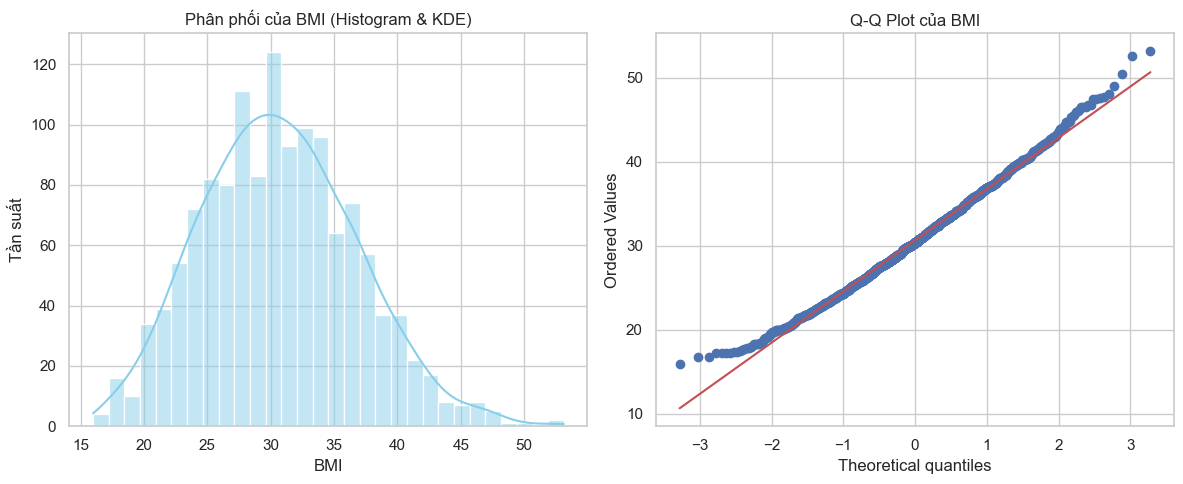

Kiểm định Shapiro-Wilk cho BMI:
Statistics=0.994, p=0.000
Nhận xét: Bác bỏ giả thuyết H0 (Dữ liệu không hoàn toàn tuân theo phân phối chuẩn).


In [17]:
# Vẽ biểu đồ Histogram và KDE cho bmi
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['bmi'], kde=True, color='skyblue', bins=30)
plt.title('Phân phối của BMI (Histogram & KDE)')
plt.xlabel('BMI')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho bmi
plt.subplot(1, 2, 2)
stats.probplot(df['bmi'], dist="norm", plot=plt)
plt.title('Q-Q Plot của BMI')

plt.tight_layout()
import os
os.makedirs('charts', exist_ok=True)
plt.savefig('charts/bmi_distribution.png', bbox_inches='tight')
plt.show()

# Kiểm định Shapiro-Wilk cho biến bmi (chỉ lấy mẫu ngẫu nhiên do data lớn nếu cần, nhưng với data này ~1300 dòng thì có thể chạy trực tiếp)
stat, p = stats.shapiro(df['bmi'])
print('Kiểm định Shapiro-Wilk cho BMI:')
print('Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Nhận xét: Không có bằng chứng để bác bỏ giả thuyết H0 (Dữ liệu có phân phối chuẩn).')
else:
    print('Nhận xét: Bác bỏ giả thuyết H0 (Dữ liệu không hoàn toàn tuân theo phân phối chuẩn).')

**Nhận xét:**
- Dựa trên biểu đồ, phân phối của `bmi` có dạng hình chuông gần đối xứng, đỉnh quanh 30, Q-Q bám khá sát đường chéo, hai đuôi lệch nhẹ (đuôi phải dài hơn). Về mặt thực tiễn, phân phối này xấp xỉ chuẩn.
- Skewness = 0.28, Kurtosis (kurtosis dư - baseline là 0 cho phân phối chuẩn) = -0.05.
- Kiểm định Shapiro-Wilk cho p-value = 2.575e-05 < 0.05. Do cỡ mẫu n lớn (≈1300), kiểm định Shapiro-Wilk rất nhạy cảm với những sai lệch nhỏ nên bác bỏ giả thuyết phân phối chuẩn. Tuy nhiên, qua quan sát thực tế (histogram, Q-Q plot), ta vẫn có thể coi `bmi` tuân theo phân phối xấp xỉ chuẩn cho mục đích phân tích.
- Lưu ý: Đề bài có đề cập đến phân phối Poisson, tuy nhiên Poisson dành cho biến đếm rời rạc, còn `bmi` và `charges` là các biến liên tục nên ta không áp dụng phân phối Poisson.

## 2.2. Phân phối của biến `charges` (Chi phí y tế)

Biến `charges` là chi phí y tế được lập hóa đơn cho bệnh nhân. Chi phí thường bị lệch phải do có một số bệnh nhân có chi phí điều trị rất cao.

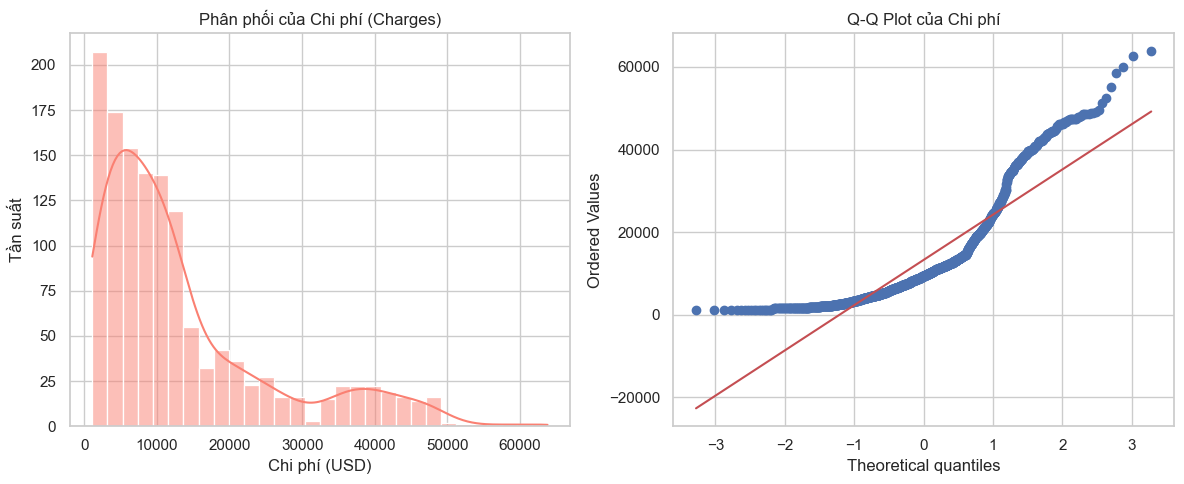

In [18]:
# Vẽ biểu đồ Histogram và KDE cho charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='salmon', bins=30)
plt.title('Phân phối của Chi phí (Charges)')
plt.xlabel('Chi phí (USD)')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho charges
plt.subplot(1, 2, 2)
stats.probplot(df['charges'], dist="norm", plot=plt)
plt.title('Q-Q Plot của Chi phí')

plt.tight_layout()
plt.savefig('charts/charges_distribution.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Biến `charges` lệch phải rất mạnh (Skewness = 1.52, Kurtosis dư = 1.60). Kiểm định Shapiro-Wilk của `charges` cũng bác bỏ phân phối chuẩn.
- Đồ thị Q-Q plot cong hẳn khỏi đường chéo, cho thấy phân phối không chuẩn.
- Nhìn biểu đồ ban đầu có vẻ giống Exponential hoặc Log-Normal. Sau khi kiểm định KS (Kolmogorov-Smirnov) và so sánh Statistic D (D nhỏ hơn nghĩa là phân phối khớp hơn; ta dùng D để đánh giá mức độ phù hợp thay vì p-value vì p-value dễ bị thổi phồng khi tham số được ước lượng từ chính dữ liệu) giữa Normal, Exponential (đã ước lượng loc/scale) và Log-Normal, ta thấy Log-Normal và Exponential tốt hơn so với chuẩn, nhưng không hoàn hảo.
- Vẽ đồ thị chồng lên (xem ở dưới) cho thấy biến `charges` là hỗn hợp của các nhóm (hút thuốc và không hút thuốc) nên không khớp trọn vẹn với phân phối đơn nào.

### 2.2.1. Chuẩn hóa biến `charges` bằng Log Transformation

Vì `charges` bị lệch phải mạnh, trong phân tích thống kê và hồi quy, người ta thường dùng phép biến đổi Logarit tự nhiên (log transformation) để kéo phân phối về gần chuẩn hơn. 
(Trong tập dữ liệu đã có sẵn cột `log_charges`, ta sẽ kiểm tra phân phối của cột này)

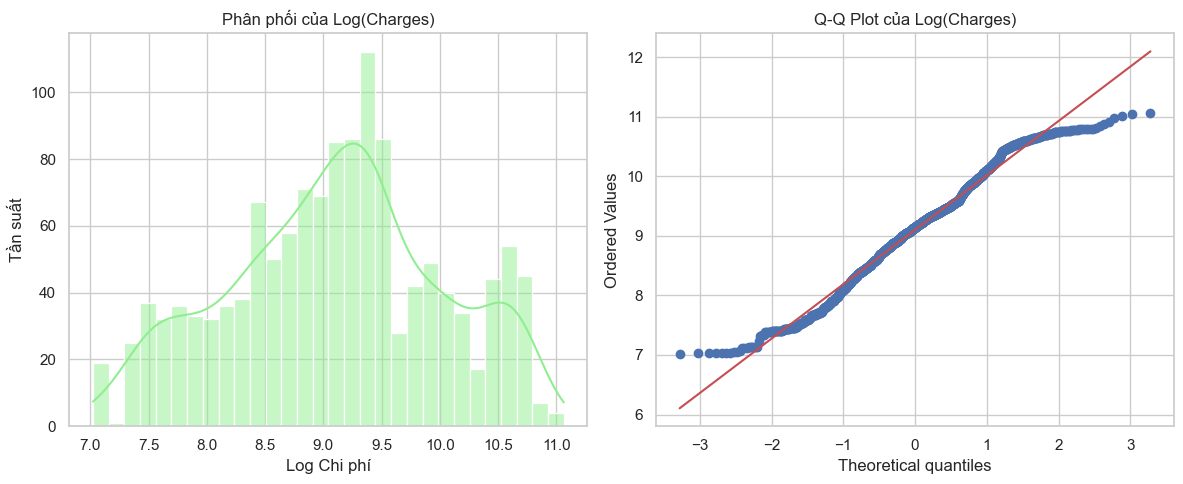

In [19]:
# Vẽ biểu đồ Histogram và KDE cho log_charges
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['log_charges'], kde=True, color='lightgreen', bins=30)
plt.title('Phân phối của Log(Charges)')
plt.xlabel('Log Chi phí')
plt.ylabel('Tần suất')

# Vẽ biểu đồ Q-Q plot cho log_charges
plt.subplot(1, 2, 2)
stats.probplot(df['log_charges'], dist="norm", plot=plt)
plt.title('Q-Q Plot của Log(Charges)')

plt.tight_layout()
plt.savefig('charts/log_charges_distribution.png', bbox_inches='tight')
plt.show()

**Nhận xét:**
- Việc log-transform đã giúp giảm độ lệch phải (Skewness giảm từ 1.52 xuống -0.09, Kurtosis giảm từ 1.60 xuống -0.63). Đồ thị histogram cho thấy phân phối đối xứng hơn rất nhiều.
- Tuy nhiên, biến `log_charges` vẫn không hoàn toàn chuẩn (Q-Q plot có dạng chữ S, đuôi hai bên phẳng, histogram có biểu hiện phân phối bimodal - nhiều đỉnh). Do `log(charges)` không chuẩn, nên `charges` không thực sự là phân phối Log-Normal chuẩn.

--- Skewness & Kurtosis (excess) ---
BMI - Skewness: 0.28, Kurtosis: -0.05
Charges - Skewness: 1.52, Kurtosis: 1.60
Log Charges - Skewness: -0.09, Kurtosis: -0.63

--- Shapiro-Wilk Test ---
BMI -> Statistic: 0.9939, p-value: 2.575e-05
Charges -> Statistic: 0.8148, p-value: 1.196e-36
Log Charges -> Statistic: 0.9833, p-value: 2.573e-11

--- Kolmogorov-Smirnov Test for Charges (Dùng Statistic D để so sánh) ---
KS-Test vs Normal      -> Statistic D: 0.1885
KS-Test vs Log-Normal  -> Statistic D: 0.0367
KS-Test vs Exponential -> Statistic D: 0.0611


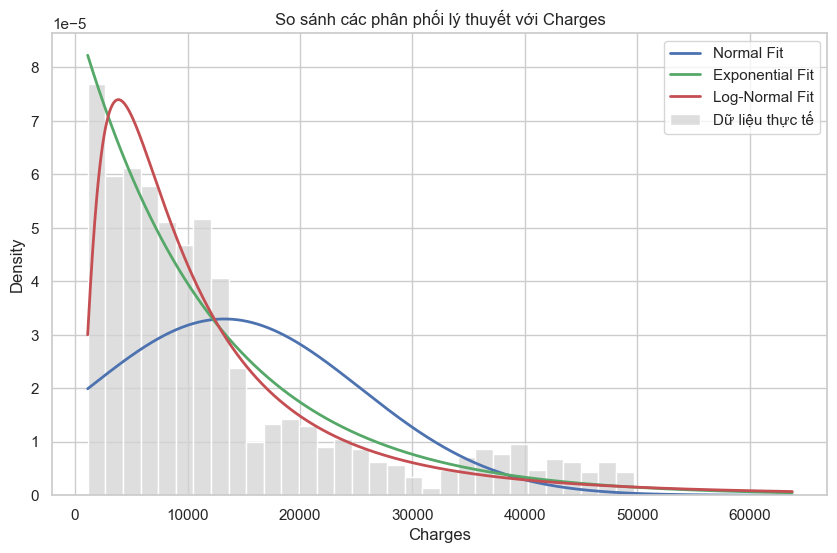

In [20]:

import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('--- Skewness & Kurtosis (excess) ---')
print(f"BMI - Skewness: {df['bmi'].skew():.2f}, Kurtosis: {df['bmi'].kurt():.2f}")
print(f"Charges - Skewness: {df['charges'].skew():.2f}, Kurtosis: {df['charges'].kurt():.2f}")
print(f"Log Charges - Skewness: {df['log_charges'].skew():.2f}, Kurtosis: {df['log_charges'].kurt():.2f}")

print('\n--- Shapiro-Wilk Test ---')
stat_b, p_b = stats.shapiro(df['bmi'])
print(f"BMI -> Statistic: {stat_b:.4f}, p-value: {p_b:.4g}")
stat_c, p_c = stats.shapiro(df['charges'])
print(f"Charges -> Statistic: {stat_c:.4f}, p-value: {p_c:.4g}")
stat_lc, p_lc = stats.shapiro(df['log_charges'])
print(f"Log Charges -> Statistic: {stat_lc:.4f}, p-value: {p_lc:.4g}")

print('\n--- Kolmogorov-Smirnov Test for Charges (Dùng Statistic D để so sánh) ---')
# KS test for Normal
norm_loc, norm_scale = stats.norm.fit(df['charges'])
stat_ks_norm, _ = stats.kstest(df['charges'], 'norm', args=(norm_loc, norm_scale))
print(f"KS-Test vs Normal      -> Statistic D: {stat_ks_norm:.4f}")

# KS test for log-normal
log_shape = np.std(df['log_charges'])
log_loc = 0
log_scale = np.exp(np.mean(df['log_charges']))
stat_ks_log, _ = stats.kstest(df['charges'], 'lognorm', args=(log_shape, log_loc, log_scale))
print(f"KS-Test vs Log-Normal  -> Statistic D: {stat_ks_log:.4f}")

# KS test for exponential
exp_loc, exp_scale = stats.expon.fit(df['charges'])
stat_ks_exp, _ = stats.kstest(df['charges'], 'expon', args=(exp_loc, exp_scale))
print(f"KS-Test vs Exponential -> Statistic D: {stat_ks_exp:.4f}")

# Vẽ biểu đồ chồng lên histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['charges'], stat='density', bins=40, color='lightgray', label='Dữ liệu thực tế')
x = np.linspace(df['charges'].min(), df['charges'].max(), 1000)
plt.plot(x, stats.norm.pdf(x, norm_loc, norm_scale), 'b-', lw=2, label='Normal Fit')
plt.plot(x, stats.expon.pdf(x, exp_loc, exp_scale), 'g-', lw=2, label='Exponential Fit')
plt.plot(x, stats.lognorm.pdf(x, log_shape, log_loc, log_scale), 'r-', lw=2, label='Log-Normal Fit')
plt.title('So sánh các phân phối lý thuyết với Charges')
plt.xlabel('Charges')
plt.ylabel('Density')
plt.legend()
plt.savefig('charts/charges_theoretical_fit.png', bbox_inches='tight')
plt.show()
